# 📥 Step 1: Data Loading (2024)

Load 2024 Sentinel-2 satellite bands for comparison with trained 2025 model.

## What This Notebook Does:
- ✅ Load multi-spectral bands (B02, B03, B04, B08) for 2024
- ✅ Check data dimensions and quality
- ✅ Visualize raw spectral bands
- ✅ Save loaded data for next steps

---

**Note:** Model trained on 2025 data. This analyzes 2024 for comparison.  
**Next:** [02_preprocessing_2024.ipynb](02_preprocessing_2024.ipynb)

## Setup: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Rasterio version: {rasterio.__version__}")

✅ Libraries imported successfully!
NumPy version: 2.4.2
Rasterio version: 1.5.0


## Configure Data Folder for 2024

**Update the `data_folder` path to point to your 2024 Sentinel-2 TIFF files.**

Expected files:
- B02_2024.tiff or B02.tiff (Blue, 490 nm)
- B03_2024.tiff or B03.tiff (Green, 560 nm)
- B04_2024.tiff or B04.tiff (Red, 665 nm)
- B08_2024.tiff or B08.tiff (NIR, 842 nm)

In [2]:
# ⚠️ MODIFY THIS PATH to point to your 2024 data folder
data_folder_2024 = "coastalImage_2024"  # Change this to your 2024 data location

print(f"📂 Looking for 2024 data in: {data_folder_2024}")
print("   Please ensure the folder contains: B02.tiff, B03.tiff, B04.tiff, B08.tiff")

📂 Looking for 2024 data in: coastalImage_2024
   Please ensure the folder contains: B02.tiff, B03.tiff, B04.tiff, B08.tiff


## Load Sentinel-2 Bands (2024)

**Sentinel-2 Bands:**
- **B02**: Blue (490 nm) - 10m resolution
- **B03**: Green (560 nm) - 10m resolution
- **B04**: Red (665 nm) - 10m resolution
- **B08**: Near-Infrared / NIR (842 nm) - 10m resolution

In [3]:
import os

def load_bands_from_folder(folder_path):
    """Load B02, B03, B04, B08 from a folder."""
    
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    
    band_map = {'B02': 'blue', 'B03': 'green', 'B04': 'red', 'B08': 'nir'}
    bands = {}
    all_files = os.listdir(folder_path)
    
    print(f"📂 Reading bands from {folder_path}...")
    
    for band_id, band_name in band_map.items():
        # Find file containing band ID
        target_file = None
        for f in all_files:
            if band_id in f and (f.endswith('.tif') or f.endswith('.tiff')):
                target_file = f
                break
        
        if target_file is None:
            raise FileNotFoundError(f"Could not find {band_id} in {folder_path}")
        
        path = os.path.join(folder_path, target_file)
        with rasterio.open(path) as src:
            print(f"   ✅ Found {band_name.upper()}: {target_file}")
            bands[band_name] = src.read(1).astype(float)
    
    return bands

# Load the 2024 bands
try:
    bands_2024 = load_bands_from_folder(data_folder_2024)
    
    B02_2024 = bands_2024['blue']
    B03_2024 = bands_2024['green']
    B04_2024 = bands_2024['red']
    B08_2024 = bands_2024['nir']
    
    print(f"✅ All bands loaded successfully!")
    print(f"\nImage dimensions: {B02_2024.shape}")
    print(f"Total pixels: {B02_2024.size:,}")
    print(f"\nBand statistics:")
    print(f"  B02 (Blue)  - Min: {B02_2024.min():.4f}, Max: {B02_2024.max():.4f}, Mean: {B02_2024.mean():.4f}")
    print(f"  B03 (Green) - Min: {B03_2024.min():.4f}, Max: {B03_2024.max():.4f}, Mean: {B03_2024.mean():.4f}")
    print(f"  B04 (Red)   - Min: {B04_2024.min():.4f}, Max: {B04_2024.max():.4f}, Mean: {B04_2024.mean():.4f}")
    print(f"  B08 (NIR)   - Min: {B08_2024.min():.4f}, Max: {B08_2024.max():.4f}, Mean: {B08_2024.mean():.4f}")
    
except Exception as e:
    print(f"❌ Error loading bands: {e}")
    print(f"\n📌 Please ensure your 2024 TIFF files are in the '{data_folder_2024}' folder")
    print(f"📌 Files should be named: B02.tiff, B03.tiff, B04.tiff, B08.tiff")

📂 Reading bands from coastalImage_2024...
   ✅ Found BLUE: B02.tiff
   ✅ Found GREEN: B03.tiff
   ✅ Found RED: B04.tiff
   ✅ Found NIR: B08.tiff
✅ All bands loaded successfully!

Image dimensions: (424, 480)
Total pixels: 203,520

Band statistics:
  B02 (Blue)  - Min: -9999.0000, Max: 0.3420, Mean: -2129.5162
  B03 (Green) - Min: -9999.0000, Max: 0.3249, Mean: -2129.5168
  B04 (Red)   - Min: -9999.0000, Max: 0.3802, Mean: -2129.5277
  B08 (NIR)   - Min: -9999.0000, Max: 0.4925, Mean: -2129.5313


## Visualize Spectral Bands (2024)

B02 - Blue Band (490 nm): actual range [0.0285, 0.0790]
B03 - Green Band (560 nm): actual range [0.0266, 0.1028]
B04 - Red Band (665 nm): actual range [0.0146, 0.0864]
B08 - NIR Band (842 nm): actual range [0.0081, 0.0936]


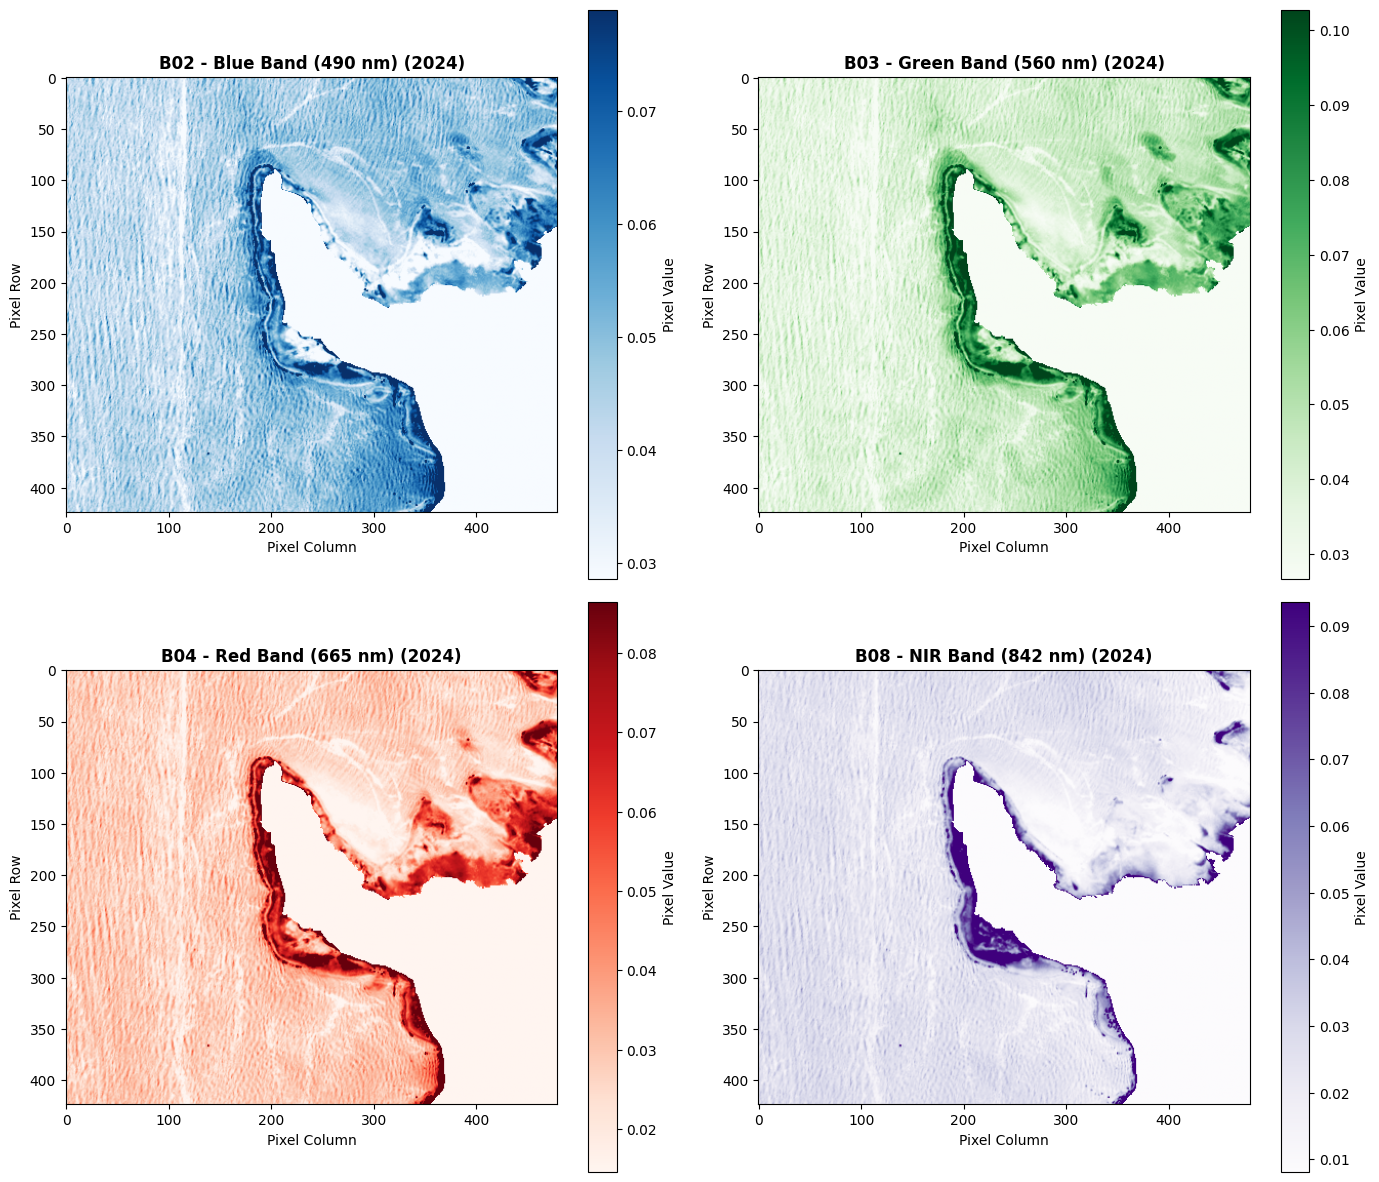

💾 Visualization saved to 'outputs/01_spectral_bands_2024.png'


In [4]:
# Visualize all four bands
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

bands = [B02_2024, B03_2024, B04_2024, B08_2024]
titles = ['B02 - Blue Band (490 nm)', 'B03 - Green Band (560 nm)', 
          'B04 - Red Band (665 nm)', 'B08 - NIR Band (842 nm)']
cmaps = ['Blues', 'Greens', 'Reds', 'Purples']

for idx, (band, title, cmap) in enumerate(zip(bands, titles, cmaps)):
    ax = axes[idx // 2, idx % 2]
    
    # Filter out nodata values (-9999) AND NaN
    band_clean = band[(band > -9999) & (~np.isnan(band))]
    
    # Calculate percentile stretch on actual data range
    vmin = np.percentile(band_clean, 2)
    vmax = np.percentile(band_clean, 98)
    
    print(f"{title}: actual range [{vmin:.4f}, {vmax:.4f}]")
    
    im = ax.imshow(band, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"{title} (2024)", fontsize=12, fontweight='bold')
    ax.set_xlabel('Pixel Column')
    ax.set_ylabel('Pixel Row')
    cbar = plt.colorbar(im, ax=ax, label='Pixel Value')

plt.tight_layout()
plt.savefig('outputs/01_spectral_bands_2024.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Visualization saved to 'outputs/01_spectral_bands_2024.png'")

## Save Loaded Bands for Next Notebook

In [5]:
# Save bands in a pickle file for next notebook
bands_2024_data = {
    'B02': B02_2024,
    'B03': B03_2024,
    'B04': B04_2024,
    'B08': B08_2024
}

with open('outputs/bands_2024.pkl', 'wb') as f:
    pickle.dump(bands_2024_data, f)

print("💾 2024 bands saved to 'outputs/bands_2024.pkl'")
print("\n✅ Step 1 Complete! Ready for preprocessing.")
print("📌 Next: Open 02_preprocessing_2024.ipynb")

💾 2024 bands saved to 'outputs/bands_2024.pkl'

✅ Step 1 Complete! Ready for preprocessing.
📌 Next: Open 02_preprocessing_2024.ipynb
